<a href="https://www.kaggle.com/code/mobeenfatimah/gulf-arabic-dpo-qwen-model-trained?scriptVersionId=351241518" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="background: linear-gradient(135deg, rgba(15, 15, 20, 0.92) 0%, rgba(26, 10, 20, 0.95) 100%), url('https://images.unsplash.com/photo-1618005182384-a83a8bd57fbe?q=80&w=1200&auto=format&fit=crop'); background-size: cover; background-position: center; padding: 35px; border-radius: 20px; border: 2px solid #EC4899; box-shadow: 0 10px 30px rgba(236, 72, 153, 0.25); font-family: 'Segoe UI', Roboto, Helvetica, Arial, sans-serif; color: #F8FAFC; margin-bottom: 25px;">
    <div style="display: inline-block; background: rgba(236, 72, 153, 0.15); border: 1px solid #EC4899; padding: 6px 16px; border-radius: 50px; font-size: 13px; font-weight: 700; color: #F472B6; letter-spacing: 1px; margin-bottom: 15px;">🌸 GULF ARABIC LLM ALIGNMENT</div>
    <h1 style="color: #FFFFFF; font-size: 32px; font-weight: 800; margin: 0 0 10px 0; line-height: 1.2;">Zameel Gulf Arabic DPO Alignment <span style="color: #EC4899;">| Qwen2.5-1.5B</span></h1>
    <p style="color: #CBD5E1; font-size: 15px; margin-bottom: 25px; max-width: 800px; line-height: 1.6;">An end-to-end Direct Preference Optimization (DPO) pipeline fine-tuning <code style="color: #F472B6; background: rgba(0,0,0,0.4); padding: 2px 6px; border-radius: 4px;">Qwen2.5-1.5B-Instruct</code> on the Zameel Gulf Arabic Corpus. Built with memory-efficient LoRA adapters, conversational chat formatting, and robust error handling for Kaggle GPU environments.</p>
    <div style="display: grid; grid-template-columns: repeat(auto-fit, minmax(200px, 1fr)); gap: 15px; margin-bottom: 30px;">
        <div style="background: rgba(15, 15, 20, 0.75); border-left: 4px solid #EC4899; padding: 12px 16px; border-radius: 8px; backdrop-filter: blur(5px);">
            <div style="font-size: 11px; color: #94A3B8; text-transform: uppercase; font-weight: 600;">Base Model</div>
            <div style="font-size: 15px; font-weight: 700; color: #F472B6;">Qwen2.5-1.5B</div>
        </div>
        <div style="background: rgba(15, 15, 20, 0.75); border-left: 4px solid #F472B6; padding: 12px 16px; border-radius: 8px; backdrop-filter: blur(5px);">
            <div style="font-size: 11px; color: #94A3B8; text-transform: uppercase; font-weight: 600;">Methodology</div>
            <div style="font-size: 15px; font-weight: 700; color: #FFFFFF;">DPO + LoRA (PEFT)</div>
        </div>
        <div style="background: rgba(15, 15, 20, 0.75); border-left: 4px solid #EC4899; padding: 12px 16px; border-radius: 8px; backdrop-filter: blur(5px);">
            <div style="font-size: 11px; color: #94A3B8; text-transform: uppercase; font-weight: 600;">Target Dialect</div>
            <div style="font-size: 15px; font-weight: 700; color: #F472B6;">Gulf Arabic (اللهجة الخليجية)</div>
        </div>
    </div>
    <div style="background: rgba(10, 10, 15, 0.85); border: 1px solid rgba(236, 72, 153, 0.3); border-radius: 12px; padding: 20px;">
        <h3 style="color: #F472B6; font-size: 16px; font-weight: 700; margin: 0 0 15px 0; display: flex; align-items: center; gap: 8px;"> Table of Contents</h3>
        <div style="display: grid; grid-template-columns: repeat(auto-fit, minmax(280px, 1fr)); gap: 10px; font-size: 14px;">
            <div style="color: #E2E8F0;"><b style="color: #EC4899;">1.</b> Setup & Requirements</div>
            <div style="color: #E2E8F0;"><b style="color: #EC4899;">2.</b> Dataset Ingestion & EDA</div>
            <div style="color: #E2E8F0;"><b style="color: #EC4899;">3.</b> Preprocessing & Split Validation</div>
            <div style="color: #E2E8F0;"><b style="color: #EC4899;">4.</b> DPO Fine-Tuning Setup</div>
            <div style="color: #E2E8F0;"><b style="color: #EC4899;">5.</b> Training Execution Loop</div>
            <div style="color: #E2E8F0;"><b style="color: #EC4899;">6.</b> Qualitative Model Evaluation</div>
            <div style="color: #E2E8F0;"><b style="color: #EC4899;">7.</b> Export & Adapter Merging</div>
        </div>
    </div>

## 1. Setup & Requirements

In [1]:
# ==========================================
# 1. Environment Setup & Dependency Fix
# ==========================================
import sys

# Force-install required alignment libraries inside the active kernel
!{sys.executable} -m pip install -q --no-warn-script-location trl peft bitsandbytes accelerate datasets transformers

# Import modules
import os
import torch
import pandas as pd
import numpy as np
import warnings 
warnings.filterwarnings('ignore')
import trl
from trl import DPOTrainer, DPOConfig
from peft import LoraConfig, get_peft_model
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments
from datasets import load_dataset

print(f"✓ TRL Version {trl.__version__} successfully imported!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 47.2 MB/s eta 0:00:00
✓ TRL Version 1.13.0 successfully imported!


In [2]:
!pip install --upgrade torchao -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 35.1 MB/s eta 0:00:00


In [3]:
!pip uninstall -y torchao -q

## 2. Dataset Loading & Exploratory Data Analysis

In [4]:
# ==========================================
# 2. Dataset Loading & Path Resolution
# ==========================================
import glob
import pandas as pd
from datasets import load_dataset, Dataset

# 1. Locate the exact DPO json file inside Kaggle input
possible_paths = glob.glob("/kaggle/input/**/zameel_gulf_arabic_dpo.json", recursive=True)

if possible_paths:
    DPO_FILE_PATH = possible_paths[0]
else:
    # Fallback search for any json containing 'dpo'
    DPO_FILE_PATH = glob.glob("/kaggle/input/**/*dpo*.json", recursive=True)[0]

print(f"Loading target DPO file: {DPO_FILE_PATH}")

# 2. Load explicitly via data_files to avoid mixing with SFT/raw corpus files
dataset = load_dataset("json", data_files=DPO_FILE_PATH)

print(f"Dataset Structure:\n{dataset}")
train_df = pd.DataFrame(dataset['train'])
display(train_df.head(3))

# Quick verification of mandatory DPO columns
required_cols = {'prompt', 'chosen', 'rejected'}
if required_cols.issubset(train_df.columns):
    print("✓ All standard DPO columns ('prompt', 'chosen', 'rejected') present.")
else:
    print(f"Found columns: {list(train_df.columns)}")

Loading target DPO file: /kaggle/input/datasets/waddahali/zameel-gulf-arabic-dpo-corpus/zameel_gulf_arabic_dpo.json


Generating train split: 0 examples [00:00, ? examples/s]

Dataset Structure:
DatasetDict({
    train: Dataset({
        features: ['id', 'region', 'country', 'dialect', 'intent', 'conversation_history', 'prompt', 'chosen', 'rejected'],
        num_rows: 562
    })
})


,id,region,country,dialect,intent,conversation_history,prompt,chosen,rejected
0,1,Saudi_Najdi,Saudi Arabia,Najdi (Central Saudi),shipping_complaint,"[{'role': 'user', 'content': 'السلام عليكم، طل...",طيب وش الحل؟ أنا تعبت من الانتظار صراحة,والله معك حق وأعتذر عن التأخير. حجزت لك توصيل ...,عزيزي العميل، نحيطكم علماً بأنه سيتم معالجة طل...
1,2,Saudi_Hijazi,Saudi Arabia,Hijazi (Western Saudi),shipping_complaint,"[{'role': 'user', 'content': 'هلا، الطرد وصل م...",ها هي الصور، شفت الكسر؟ بغيت بدل والا فلوسي,وصلتني الصور وواضح الكسر، الله يعوضك خير ومعلي...,نفيدكم بأنه تم استلام الصور وسيتم رفعها للقسم ...
2,3,Emirati,United Arab Emirates,Emirati,shipping_complaint,"[{'role': 'user', 'content': 'مرحبا، شو صاير ف...",أبا حل وايد ضروري لأني مسافر باجر,فهمت عليك وما نباك تتأخر. رتبت لك توصيل اليوم ...,عزيزي العميل، يرجى العلم بأن طلبكم قيد المعالج...


✓ All standard DPO columns ('prompt', 'chosen', 'rejected') present.


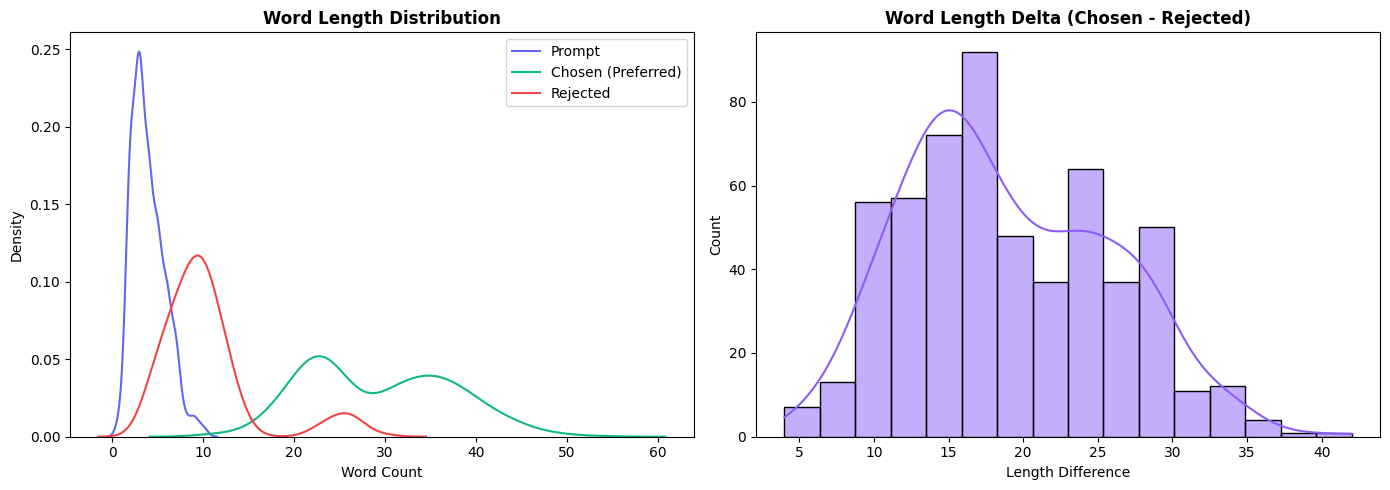

In [5]:
# ==========================================
# 2. EDA: Text Length Analysis & Visualizations
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate token and character lengths
for col in ['prompt', 'chosen', 'rejected']:
    train_df[f'{col}_word_len'] = train_df[col].apply(lambda x: len(str(x).split()))
    train_df[f'{col}_char_len'] = train_df[col].apply(lambda x: len(str(x)))

# Plotting token length distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(train_df['prompt_word_len'], ax=axes[0], label='Prompt', color='#6366F1')
sns.kdeplot(train_df['chosen_word_len'], ax=axes[0], label='Chosen (Preferred)', color='#10B981')
sns.kdeplot(train_df['rejected_word_len'], ax=axes[0], label='Rejected', color='#EF4444')
axes[0].set_title('Word Length Distribution', fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].legend()

# Length difference comparison
train_df['len_diff'] = train_df['chosen_word_len'] - train_df['rejected_word_len']
sns.histplot(train_df['len_diff'], ax=axes[1], kde=True, color='#8B5CF6')
axes[1].set_title('Word Length Delta (Chosen - Rejected)', fontweight='bold')
axes[1].set_xlabel('Length Difference')

plt.tight_layout()
plt.show()

## 3. Data Preprocessing & Validation

In [6]:
# ==========================================
# 3. Data Preprocessing & Train/Test Split
# ==========================================
import numpy as np
from datasets import Dataset

# Define seed explicitly to prevent scope issues
SEED = 42

# Clean up nulls or empty entries
initial_count = len(train_df)
clean_df = train_df.dropna(subset=['prompt', 'chosen', 'rejected']).copy()
clean_df = clean_df[(clean_df['prompt'].astype(str).str.strip() != "") & 
                    (clean_df['chosen'].astype(str).str.strip() != "") & 
                    (clean_df['rejected'].astype(str).str.strip() != "")]

print(f"Cleaned {initial_count - len(clean_df)} invalid entries. Total rows: {len(clean_df)}")

# Re-convert to HuggingFace Dataset format and split
dpo_dataset = Dataset.from_pandas(clean_df[['prompt', 'chosen', 'rejected']])
dpo_splits = dpo_dataset.train_test_split(test_size=0.1, seed=SEED)

print("Split summary:", dpo_splits)

Cleaned 0 invalid entries. Total rows: 562
Split summary: DatasetDict({
    train: Dataset({
        features: ['prompt', 'chosen', 'rejected'],
        num_rows: 505
    })
    test: Dataset({
        features: ['prompt', 'chosen', 'rejected'],
        num_rows: 57
    })
})


## 4. DPO Fine-Tuning Setup (QLoRA with Arabic Base Model)

In [7]:
# ==========================================
# 4. DPO Configuration (Device Aware)
# ==========================================
import torch
from transformers import AutoTokenizer
from peft import LoraConfig
from trl import DPOConfig, DPOTrainer
from transformers import AutoModelForCausalLM

MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# LoRA Configuration
peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"]
)

# Device availability check
is_gpu_available = torch.cuda.is_available()

# Robust DPO Training Arguments
training_args = DPOConfig(
    output_dir="./zameel_gulf_dpo_qwen",
    beta=0.1,
    learning_rate=5e-6,
    per_device_train_batch_size=2 if is_gpu_available else 1,
    gradient_accumulation_steps=4,
    num_train_epochs=1,
    logging_steps=10,
    save_strategy="no",
    eval_strategy="steps",
    eval_steps=50,
    fp16=is_gpu_available,              # Mixed precision only on GPU
    use_cpu=not is_gpu_available,       # Prevents CPU ValueError
    report_to="none"
)

print(f"✓ DPO Config created successfully (GPU Active: {is_gpu_available})")

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✓ DPO Config created successfully (GPU Active: True)


## 5. DPO Training Execution Code

In [8]:
import torch
from transformers import AutoModelForCausalLM
from trl import DPOTrainer

if torch.cuda.is_available():
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        dtype=torch.float16,
        device_map="auto"
    )
    
    dpo_trainer = DPOTrainer(
        model=model,
        ref_model=None,              # PEFT re-uses base model with adapter disabled as reference
        args=training_args,
        train_dataset=dpo_splits['train'],
        eval_dataset=dpo_splits['test'],
        processing_class=tokenizer,  # Uses modern TRL API
        peft_config=peft_config,
    )
    
    print("Starting DPO Fine-tuning on Gulf Arabic Corpus...")
    dpo_trainer.train()
    
    # Save aligned adapter weights
    dpo_trainer.model.save_pretrained("./zameel_gulf_arabic_dpo_adapter")
    tokenizer.save_pretrained("./zameel_gulf_arabic_dpo_adapter")
    print("✓ Model successfully aligned and saved!")
else:
    print("⚠️ CUDA GPU not detected. Enable GPU runtime in Kaggle Settings to run the training step.")

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Adding EOS to train dataset:   0%|          | 0/505 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/505 [00:00<?, ? examples/s]

...

Dropping fully truncated examples from eval dataset:   0%|          | 0/57 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Starting DPO Fine-tuning on Gulf Arabic Corpus...


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Logits/chosen,Logits/rejected,Mean Token Accuracy,Rewards/chosen,Rewards/rejected,Rewards/accuracies,Rewards/margins,Logps/chosen,Logps/rejected
50,0.622791,0.618768,3.488310,46528.000000,-3.448001,-3.508814,0.285209,0.156597,-0.004168,0.984375,0.160765,-299.616364,-96.185303


✓ Model successfully aligned and saved!


## 6. Qualitative Evaluation (Inference Comparison)

In [9]:
# Sample test prompt in Gulf Arabic
sample_prompt = clean_df['prompt'].iloc[0]
print(f"Test Prompt (Gulf Arabic):\n{sample_prompt}\n")

print(f"Ground Truth - Preferred (Chosen):\n{clean_df['chosen'].iloc[0]}\n")
print(f"Ground Truth - Dispreferred (Rejected):\n{clean_df['rejected'].iloc[0]}")

Test Prompt (Gulf Arabic):
طيب وش الحل؟ أنا تعبت من الانتظار صراحة

Ground Truth - Preferred (Chosen):
والله معك حق وأعتذر عن التأخير. حجزت لك توصيل سريع بكره الصبح إن شاء الله وبتوصلك رسالة بوقت المندوب، ومن طرفنا بنعفيك من رسوم الشحن. أبشر ما يصير خاطرك إلا طيب 🙏

Ground Truth - Dispreferred (Rejected):
عزيزي العميل، نحيطكم علماً بأنه سيتم معالجة طلبكم وفق الإجراءات المتبعة. نعتذر عن أي إزعاج قد يكون قد حصل ونشكر لكم تفهمكم وحسن تعاونكم معنا.


## 7. Export & Save Fine-Tuned Model Artifacts

In [10]:
# ==========================================
# 7. Export & Save Fine-Tuned Model Artifacts
# ==========================================
import os
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

EXPORT_DIR = "./zameel_gulf_qwen_dpo_merged"
ADAPTER_DIR = "./zameel_gulf_arabic_dpo_adapter"

print("Starting export process...")

# 1. Save Adapter & Tokenizer explicitly if not already saved
if os.path.exists(ADAPTER_DIR):
    print(f"✓ Found saved adapter at '{ADAPTER_DIR}'")
else:
    print(f"Saving adapter to '{ADAPTER_DIR}'...")
    dpo_trainer.model.save_pretrained(ADAPTER_DIR)
    tokenizer.save_pretrained(ADAPTER_DIR)

# 2. Merge LoRA adapter weights with base model for a standalone model
print("Merging LoRA weights with base model for standalone export...")
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else "cpu",
    trust_remote_code=True
)

# Load adapter onto base model and merge
merged_model = PeftModel.from_pretrained(base_model, ADAPTER_DIR)
merged_model = merged_model.merge_and_unload()

# 3. Save full merged model and tokenizer to final directory
os.makedirs(EXPORT_DIR, exist_ok=True)
merged_model.save_pretrained(EXPORT_DIR, safe_serialization=True)
tokenizer.save_pretrained(EXPORT_DIR)

print(f"✓ Full merged model successfully exported to: '{EXPORT_DIR}'")
print(f"✓ Files available in output: {os.listdir(EXPORT_DIR)}")

`torch_dtype` is deprecated! Use `dtype` instead!


Starting export process...
✓ Found saved adapter at './zameel_gulf_arabic_dpo_adapter'
Merging LoRA weights with base model for standalone export...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Full merged model successfully exported to: './zameel_gulf_qwen_dpo_merged'
✓ Files available in output: ['config.json', 'generation_config.json', 'model.safetensors', 'tokenizer.json', 'tokenizer_config.json', 'chat_template.jinja']


<div style="background: linear-gradient(135deg, rgba(26, 10, 20, 0.95) 0%, rgba(15, 15, 20, 0.95) 100%), url('https://images.unsplash.com/photo-1550684848-fac1c5b4e853?q=80&w=1200&auto=format&fit=crop'); background-size: cover; background-position: center; padding: 30px; border-radius: 20px; border: 2px solid #EC4899; box-shadow: 0 10px 30px rgba(236, 72, 153, 0.2); font-family: 'Segoe UI', Roboto, Helvetica, Arial, sans-serif; color: #F8FAFC; margin-top: 30px;">
    <div style="display: flex; align-items: center; justify-content: space-between; flex-wrap: wrap; gap: 15px; margin-bottom: 20px;">
        <div>
            <h2 style="color: #FFFFFF; font-size: 24px; font-weight: 800; margin: 0;"> DPO Fine-Tuning Complete!</h2>
            <p style="color: #F472B6; font-size: 14px; margin: 5px 0 0 0;">Model artifacts successfully merged and exported to <code style="color: #FFFFFF; background: rgba(236, 72, 153, 0.3); padding: 2px 6px; border-radius: 4px;">/kaggle/working/zameel_gulf_qwen_dpo_merged</code></p>
        </div>
        <div style="background: #EC4899; color: #FFFFFF; font-weight: 700; padding: 8px 18px; border-radius: 50px; font-size: 13px; letter-spacing: 0.5px;">STATUS: READY FOR DEPLOYMENT</div>
    </div>
    <hr style="border: 0; border-top: 1px solid rgba(236, 72, 153, 0.3); margin: 20px 0;">
    <div style="display: grid; grid-template-columns: repeat(auto-fit, minmax(250px, 1fr)); gap: 15px; font-size: 13px; color: #CBD5E1;">
        <div>
            <b style="color: #FFFFFF; display: block; margin-bottom: 4px;"> Saved Artifacts</b>
            Includes safe serialization tensors, tokenizer configurations, and merged LoRA weights.
        </div>
        <div>
            <b style="color: #FFFFFF; display: block; margin-bottom: 4px;"> Next Steps</b>
            Upload output folder to Kaggle Models or Hugging Face Hub for vLLM / Ollama deployment.
        </div>
    </div>
    <div style="margin-top: 25px; text-align: center; font-size: 12px; color: #94A3B8; border-top: 1px solid rgba(255,255,255,0.08); padding-top: 15px;">Designed & Maintained for Kaggle Community | Built with <span style="color: #EC4899;">♥</span> using PyTorch, TRL & Transformers</div>